# 06 · Expansión del corpus a Competencias (Escalera 2)

**Alcance:** materializar la entidad sintética **Prueba Regional** para dar cuerpo al dominio
de Competencias (el hallazgo de volumen alto y demanda cero), integrarla al corpus y
reejecutar la escalera. Aquí Competencias deja de ser una observación del EDA y se convierte
en la contribución de ingeniería del trabajo.

## 1. Contexto y objetivo

Las consultas de competencias no tenían documento relevante en la v1: un **vacío de
cobertura**, no un fallo del recuperador. La Prueba Regional (``Atletismo Pre-Juvenil en
Región Caribe 1``) no es un campo, sino la composición de disciplina × categoría × fase ×
región. Materializarla: (i) vuelve informativo el Recall@100 al pasar de 17 a cientos de
documentos, (ii) da poder estadístico, y (iii) somete la ontología (P3) a su prueba más dura,
un dominio construido por composición ontológica.

### 1.1 Privacidad
Competencias gira en torno a disciplinas, fases y regiones, no personas. Los volúmenes
(participaciones, resultados) entran solo como **conteos agregados** en los metadatos; ninguna
fila con datos personales entra al índice.

## 2. Núcleo de recuperación (inline, reproducible)

In [1]:
import json, sys, time, math, re, unicodedata
from collections import Counter
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.25})
RAIZ = Path.cwd();
if RAIZ.name=="notebooks": RAIZ=RAIZ.parent
EXP = RAIZ/"experimentos"; DATA = RAIZ/"data"
cfg = yaml.safe_load((EXP/"config.yaml").read_text(encoding="utf-8"))
ontologia = yaml.safe_load((EXP/cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))
cargar = lambda p:[json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
tiene_gold = lambda q: any(g>0 for g in q.values())

# métricas
def _g(q,d): return float(q.get(d,0.0))
def dcg(r,q,k): return sum((2.0**_g(q,d)-1)/math.log2(i+1) for i,d in enumerate(r[:k],1) if _g(q,d)>0)
def ndcg(r,q,k):
    idl=sorted((g for g in q.values() if g>0),reverse=True); idcg=sum((2.0**g-1)/math.log2(i+1) for i,g in enumerate(idl[:k],1))
    return 0.0 if idcg==0 else dcg(r,q,k)/idcg
def recall(r,q,k):
    rel={d for d,g in q.items() if g>0}; return 0.0 if not rel else sum(1 for d in r[:k] if d in rel)/len(rel)
def mrr(r,q,k):
    for i,d in enumerate(r[:k],1):
        if _g(q,d)>0: return 1.0/i
    return 0.0
def prec(r,q,k): return 0.0 if k==0 else sum(1 for d in r[:k] if _g(q,d)>0)/k
def ap(r,q,k):
    rel={d for d,g in q.items() if g>0}
    if not rel: return 0.0
    ac,s=0,0.0
    for i,d in enumerate(r[:k],1):
        if d in rel: ac+=1; s+=ac/i
    return s/min(len(rel),k)
# bm25
_ST=set("el la los las un una unos unas de del a ante con en para por que y o u se su sus lo al es son como mas pero sin sobre entre cada ya cuando donde cual quien cuanto muy este esta estos".split())
def tok(t):
    t=unicodedata.normalize("NFKD",t.lower()); t="".join(c for c in t if not unicodedata.combining(c))
    return [x for x in re.findall(r"[a-z0-9]+",t) if x not in _ST and len(x)>1]
class BM25:
    def __init__(s,k1=1.5,b=0.75): s.k1,s.b=k1,b
    def fit(s,ids,txt):
        s.ids=list(ids); s.tf=[Counter(tok(t)) for t in txt]; s.len=[sum(c.values()) for c in s.tf]
        s.avg=(sum(s.len)/len(s.len)) if s.len else 0.0; df=Counter()
        for c in s.tf: df.update(c.keys())
        n=len(s.tf); s.idf={t:math.log(1+(n-d+0.5)/(d+0.5)) for t,d in df.items()}; return s
    def buscar(s,q):
        qt=tok(q); sc=np.zeros(len(s.ids))
        for i,tf in enumerate(s.tf):
            a=0.0
            for t in qt:
                if t in tf:
                    f=tf[t]; a+=s.idf.get(t,0)*f*(s.k1+1)/(f+s.k1*(1-s.b+s.b*s.len[i]/(s.avg or 1)))
            sc[i]=a
        return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _l2(m):
    n=np.linalg.norm(m,axis=1,keepdims=True); n[n==0]=1.0; return m/n
class STEnc:
    def __init__(s,modelo):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel,"all_tied_weights_keys"): PreTrainedModel.all_tied_weights_keys={}
        from sentence_transformers import SentenceTransformer
        s.m=SentenceTransformer(modelo,trust_remote_code=True); s.nombre=modelo.split("/")[-1]
        s.dim=s.m.get_sentence_embedding_dimension()
    def encode(s,txt): return _l2(s.m.encode(list(txt),convert_to_numpy=True,normalize_embeddings=False).astype(np.float32))
class Dense:
    def __init__(s,enc): s.enc=enc
    def fit(s,ids,txt): s.ids=list(ids); s.mat=s.enc.encode(txt); return s
    def buscar(s,q):
        qv=s.enc.encode([q])[0]; sc=s.mat@qv; return [(s.ids[i],float(sc[i])) for i in np.argsort(-sc)]
def _norm(x):
    x=unicodedata.normalize("NFKD",x.lower()); return "".join(c for c in x if not unicodedata.combining(c))
def rrf(a,b,k=60):
    ra={d:i+1 for i,(d,_) in enumerate(a)}; rb={d:i+1 for i,(d,_) in enumerate(b)}
    ds=[d for d,_ in a]+[d for d,_ in b if d not in ra]; big=len(ds)+k+1
    fus={d:1/(k+ra.get(d,big))+1/(k+rb.get(d,big)) for d in ds}
    return sorted(ds,key=lambda d:(-fus[d],d)), fus
class Detector:
    def __init__(s,onto):
        s.t=[]
        for cl,cu in onto.get("clases",{}).items():
            for x in [cl,*cu.get("sinonimos",[])]: s.t.append((_norm(x),cl))
        s.p=re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases(s,q):
        cq=_norm(q); return {c for t,c in s.t if t and t in cq}
    def np_(s,q):
        tks=s.p.findall(q)
        if not tks: return False
        pr=q.strip().split()[:1]; cand=[t for t in tks if not (pr and t==pr[0])]
        return any(_norm(t) not in {tt for tt,_ in s.t} for t in cand)
CONFIGS={1:"Denso puro",2:"Denso + ontología",3:"Híbrido (sin ontología)",4:"Híbrido + ontología",5:"Híbrido + ontología + realce"}
NB_BM25="BM25 (referencia léxica)"
class Motor:
    def __init__(s,docs,enc,onto,k1,b,krrf,lam):
        s.ids=[d["id"] for d in docs]; s.k=krrf; s.lam=lam; s.det=Detector(onto)
        s.ent={d["id"]:set(d["metadatos_ontologia"].get("entidades_principales",[])) for d in docs}
        s.esnp={d["id"]:bool(d.get("nombre_propio_buscable",False)) for d in docs}
        de=[d["descripcion"] for d in docs]; on=[d["texto_indexable"] for d in docs]
        s.bd=BM25(k1,b).fit(s.ids,de); s.bo=BM25(k1,b).fit(s.ids,on)
        s.dd=Dense(enc).fit(s.ids,de); s.do=Dense(enc).fit(s.ids,on)
    def ind(s,q,d):
        if s.det.clases(q)&s.ent.get(d,set()): return 1
        if s.det.np_(q) and s.esnp.get(d): return 1
        return 0
    def rec(s,cfg,q):
        if cfg==0: return [d for d,_ in s.bd.buscar(q)]
        if cfg==1: return [d for d,_ in s.dd.buscar(q)]
        if cfg==2: return [d for d,_ in s.do.buscar(q)]
        if cfg==3: return rrf(s.bd.buscar(q),s.dd.buscar(q),s.k)[0]
        if cfg==4: return rrf(s.bo.buscar(q),s.do.buscar(q),s.k)[0]
        _,f=rrf(s.bo.buscar(q),s.do.buscar(q),s.k); fin={d:v*(1+s.lam*s.ind(q,d)) for d,v in f.items()}
        return sorted(fin,key=lambda d:(-fin[d],d))
def evaluar(docs,consultas,qrels):
    enc=STEnc(cfg["encoder"]["modelo_st"])
    mot=Motor(docs,enc,ontologia,cfg["bm25"]["k1"],cfg["bm25"]["b"],cfg["fusion"]["k_rrf"],cfg["realce"]["lambda"])
    confs=[(0,NB_BM25)]+list(CONFIGS.items())
    cg=[c for c in consultas if tiene_gold(qrels.get(c["id"],{}))]
    por={n:{} for _,n in confs}
    for num,n in confs:
        for c in consultas:
            r=mot.rec(num,c["texto"])
            if tiene_gold(qrels.get(c["id"],{})):
                por[n][c["id"]]={"ndcg@10":ndcg(r,qrels[c["id"]],10),"recall@100":recall(r,qrels[c["id"]],100),
                                 "mrr@10":mrr(r,qrels[c["id"]],10),"p@10":prec(r,qrels[c["id"]],10)}
    ests=sorted({c["estrato"] for c in cg}); idsg=[c["id"] for c in cg]
    idse={e:[c["id"] for c in cg if c["estrato"]==e] for e in ests}
    def agg(n,ids,m):
        v=[por[n][i][m] for i in ids if i in por[n]]; return float(np.mean(v)) if v else float("nan")
    return enc,mot,confs,por,ests,idsg,idse,agg,cg
print("Núcleo de recuperación listo.")

Núcleo de recuperación listo.


## 3. Materialización de la Prueba Regional

**Descripción técnica.** Se componen los catálogos locales (disciplinas, regiones, conteos) en
documentos con el mismo esquema del corpus. El código equivale a
`experimentos/construir_competencias.py`; lo ejecutamos y cargamos el resultado.

In [2]:
import subprocess
print(subprocess.run([sys.executable,"construir_competencias.py"],cwd=EXP,capture_output=True,text=True).stdout)
comp_docs = cargar(EXP/"corpus/corpus_competencias.jsonl")
v1_docs = cargar(EXP/cfg["rutas"]["corpus"])
docs = v1_docs + comp_docs
print(f"corpus combinado: {len(v1_docs)} reportes + {len(comp_docs)} pruebas regionales = {len(docs)} docs")
ej=comp_docs[0]; print("\nEjemplo Prueba Regional:\n ",ej["titulo"],"\n ",ej["descripcion"][:220],"...")

{
  "n_documentos_competencias": 816,
  "disciplinas_distintas": 102,
  "regiones": 8,
  "fases_como_atributo": 4,
  "ejemplo_titulo": "Prueba Regional: Actividades Subacuáticas (Única) — Región Amazonía"
}

corpus combinado: 17 reportes + 816 pruebas regionales = 833 docs

Ejemplo Prueba Regional:
  Prueba Regional: Actividades Subacuáticas (Única) — Región Amazonía 
  La Prueba Regional: Actividades Subacuáticas (Única) — Región Amazonía es una prueba de competencia del sistema de gestión deportiva, correspondiente a la disciplina Actividades Subacuáticas en la categoría Única (indivi ...


## 4. Consultas de Competencias con objetivo real

**Descripción técnica.** Se generan consultas naturales sobre una muestra de Pruebas
Regionales (variando la formulación: nombre compuesto, "resultados de X en Y", con fase),
cada una con su documento objetivo. Se combinan con el conjunto real de la Escalera 1.

In [3]:
import random, re as _re
rng=random.Random(42); muestra=rng.sample(comp_docs,25)
FASES=["fase municipal","fase departamental","fase regional","fase nacional"]
cons_comp=[]; qr_comp={}
for i,d in enumerate(muestra,1):
    m=_re.match(r"Prueba Regional: (.+?) \((.+?)\) — Región (.+)",d["titulo"])
    sp,ca,rg=m.group(1),m.group(2),m.group(3)
    formas=[f"{sp} {ca} en Región {rg}",f"resultados de {sp} en {rg}",f"{sp} categoría {ca} {rng.choice(FASES)} en {rg}"]
    qid=f"c{i:03d}"; cons_comp.append({"id":qid,"texto":formas[i%3],"estrato":"competencias","reporte_objetivo":d["id"],"menciona_nombre_propio":False})
    qr_comp[qid]={d["id"]:2.0}
consultas = cargar(EXP/"datos/consultas_real.jsonl") + cons_comp
qrels = {**{r["id"]:r["relevancia"] for r in cargar(EXP/"datos/qrels_real.jsonl")}, **qr_comp}
print(f"{len(consultas)} consultas ({len(cons_comp)} de competencias). Ejemplos:",[c["texto"] for c in cons_comp[:3]])

96 consultas (25 de competencias). Ejemplos: ['resultados de Porrismo en Orinoquia', 'Baloncesto categoría Única fase nacional en Caribe 2', 'Ajedrez Integrado Juvenil en Región Caribe 1']


## 5. Reejecución de la escalera sobre el corpus ampliado

**Descripción técnica.** Se codifican los 833 documentos con el encoder real y se corre la
escalera. Con un corpus de cientos de documentos, Recall@100 por fin discrimina.

In [4]:
enc,mot,confs,por,ests,idsg,idse,agg,cg = evaluar(docs,consultas,qrels)
orden=[n for _,n in confs]
tabla=pd.DataFrame({m:{n:agg(n,idsg,m) for n in orden} for m in ["ndcg@10","mrr@10","recall@100","p@10"]}).loc[orden]
print("Encoder:",enc.nombre,"| docs:",len(docs),"| consultas con gold:",len(cg))
tabla.style.highlight_max(subset=["ndcg@10","mrr@10","recall@100"],color="#c9f0c9").format("{:.3f}")

Encoder: jina-embeddings-v3 | docs: 833 | consultas con gold: 96


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.890,0.853,1.000,0.100
Denso puro,0.840,0.815,0.958,0.092
Denso + ontología,0.905,0.891,1.000,0.095
Híbrido (sin ontología),0.896,0.865,1.000,0.099
Híbrido + ontología,0.929,0.905,1.000,0.100
Híbrido + ontología + realce,0.941,0.921,1.000,0.100


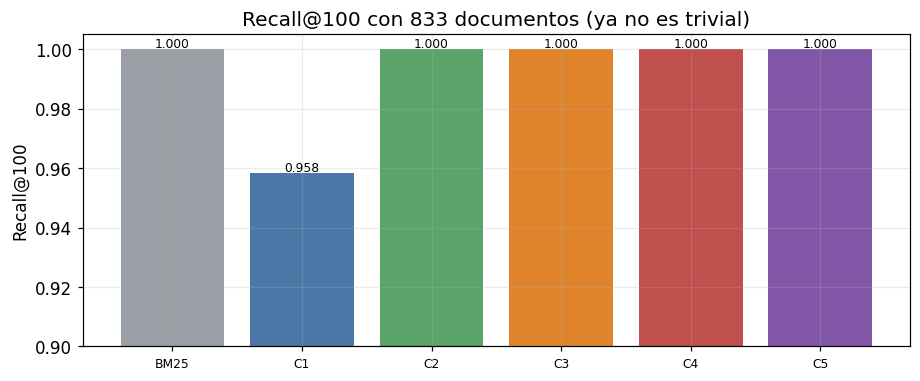

,Recall@100
BM25 (referencia léxica),1.000
Denso puro,0.958
Denso + ontología,1.000
Híbrido (sin ontología),1.000
Híbrido + ontología,1.000
Híbrido + ontología + realce,1.000


In [5]:
# Recall@100 ya discrimina: ¿qué configuración PIERDE documentos a escala?
rec=pd.Series({n:agg(n,idsg,"recall@100") for n in orden}).rename("Recall@100")
fig,ax=plt.subplots(figsize=(8.5,3.6))
ax.bar(range(len(orden)),rec.values,color=["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])
ax.set_xticks(range(len(orden))); ax.set_xticklabels([f"C{i}" if isinstance(i,int) and i>0 else "BM25" for i,_ in confs],fontsize=8)
ax.set_ylim(0.9,1.005); ax.set_ylabel("Recall@100"); ax.set_title(f"Recall@100 con {len(docs)} documentos (ya no es trivial)")
for i,v in enumerate(rec.values): ax.text(i,v+0.0007,f"{v:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.show()
rec.to_frame()

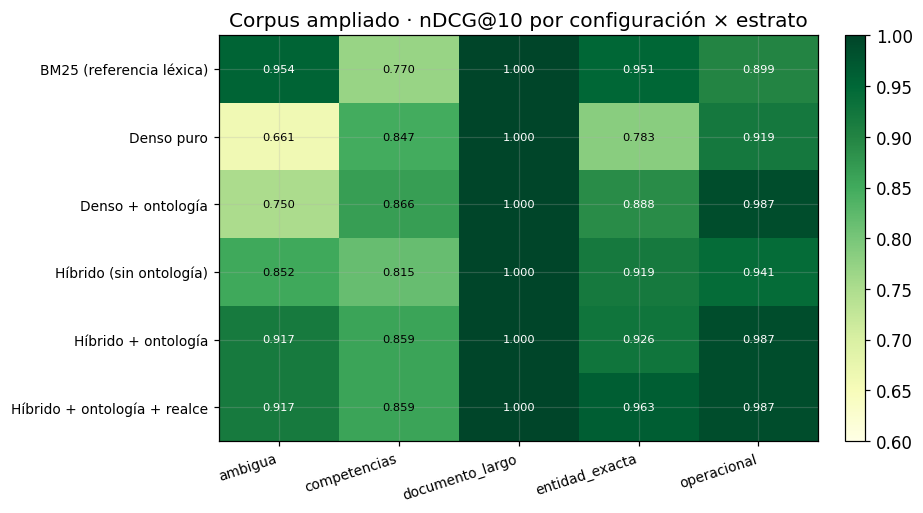

In [6]:
# nDCG@10 por estrato: incluye competencias (antes vacío de cobertura)
dfe=pd.DataFrame({e:{n:agg(n,idse[e],"ndcg@10") for n in orden} for e in ests})
import numpy as np
M=dfe.values
fig,ax=plt.subplots(figsize=(8.5,4.8))
im=ax.imshow(M,cmap="YlGn",vmin=0.6,vmax=1.0,aspect="auto")
ax.set_xticks(range(len(dfe.columns))); ax.set_xticklabels(dfe.columns,rotation=18,ha="right",fontsize=9)
ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden,fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j,i,f"{M[i,j]:.3f}",ha="center",va="center",fontsize=7.5,color="black" if M[i,j]<0.88 else "white")
ax.set_title("Corpus ampliado · nDCG@10 por configuración × estrato"); fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
plt.tight_layout(); plt.show()

### 5.4 Visualizaciones de diagnóstico (paquete estándar de IR)

Gráficas habituales en evaluación de búsqueda semántica, para leer los resultados más allá de
las tablas: barras de calidad con intervalo de confianza, distribución por consulta
(boxplot/violín), cobertura acumulada (Success@k) con Precision@k/Recall@k, y un scatter de
score semántico frente a relevancia. Los rankings se recomputan una sola vez.

In [7]:
# --- setup de visualizaciones ---
import numpy as _np
_orden = [n for _, n in confs]
_COL = {n: c for n, c in zip(_orden, ["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])}
_etq = [("C%d" % i if isinstance(i, int) and i > 0 else "BM25") for i, _ in confs]
_rank = {n: {c["id"]: mot.rec(num, c["texto"]) for c in consultas} for num, n in confs}
_gold = cg
def _bic(vals, n=2000, seed=42):
    v = _np.array(vals, float); rng = _np.random.default_rng(seed)
    m = _np.array([rng.choice(v, len(v), replace=True).mean() for _ in range(n)])
    return v.mean(), _np.percentile(m, 2.5), _np.percentile(m, 97.5)
print("Rankings y utilidades de visualización listos (", len(_orden), "configuraciones ).")

Rankings y utilidades de visualización listos ( 6 configuraciones ).


**Barras de calidad global.** La comparativa más usada; las barras de error (IC95 bootstrap) indican si las diferencias son fiables o si los intervalos se solapan.

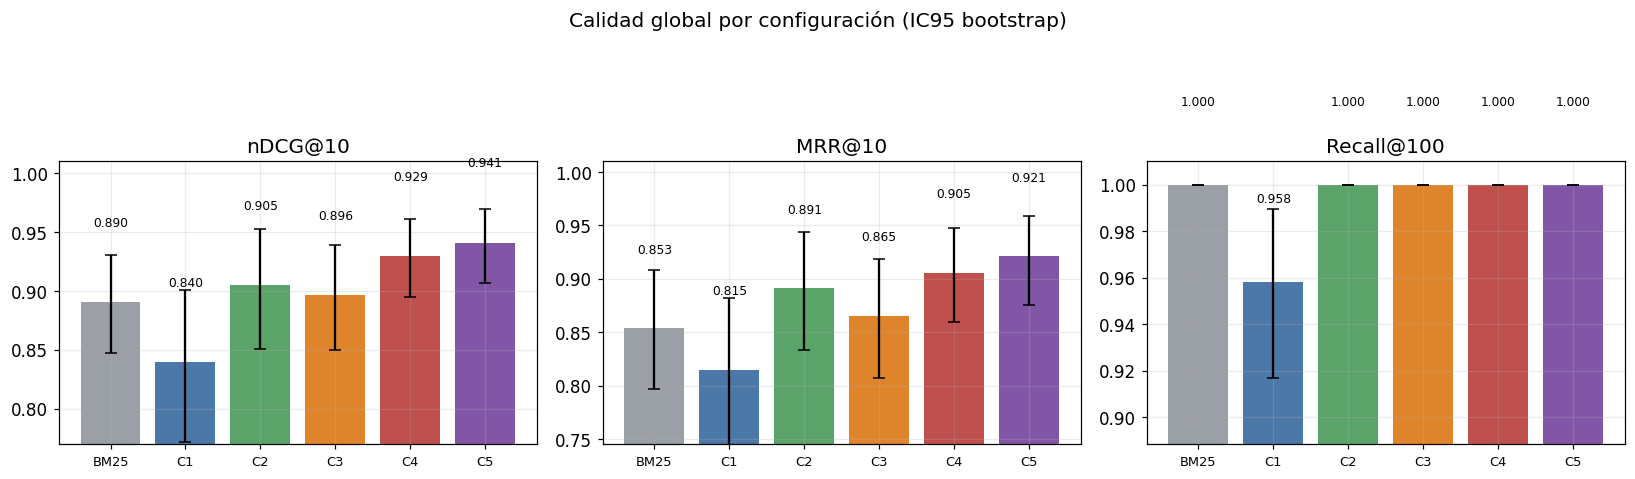

In [8]:
# Barras de calidad global con IC95 bootstrap
_mets = [("nDCG@10", lambda r, q: ndcg(r, q, 10)),
         ("MRR@10", lambda r, q: mrr(r, q, 10)),
         ("Recall@100", lambda r, q: recall(r, q, 100))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom, fn) in zip(axes, _mets):
    vals, los, his = [], [], []
    for n in _orden:
        s = [fn(_rank[n][c["id"]], qrels[c["id"]]) for c in _gold]
        m, lo, hi = _bic(s); vals.append(m); los.append(m - lo); his.append(hi - m)
    ax.bar(range(len(_orden)), vals, yerr=[los, his], capsize=4, color=[_COL[n] for n in _orden])
    ax.set_xticks(range(len(_orden))); ax.set_xticklabels(_etq, fontsize=8.5); ax.set_title(nom)
    ax.set_ylim(max(0, min(vals) - 0.07), 1.01)
    for i, v in enumerate(vals): ax.text(i, v + max(his) + 0.003, f"{v:.3f}", ha="center", fontsize=8)
fig.suptitle("Calidad global por configuración (IC95 bootstrap)", y=1.03); plt.tight_layout(); plt.show()

**Distribución por consulta.** Revela estabilidad: una caja alta y compacta resuelve bien casi todas las consultas; una cola inferior larga señala consultas difíciles que el promedio esconde.

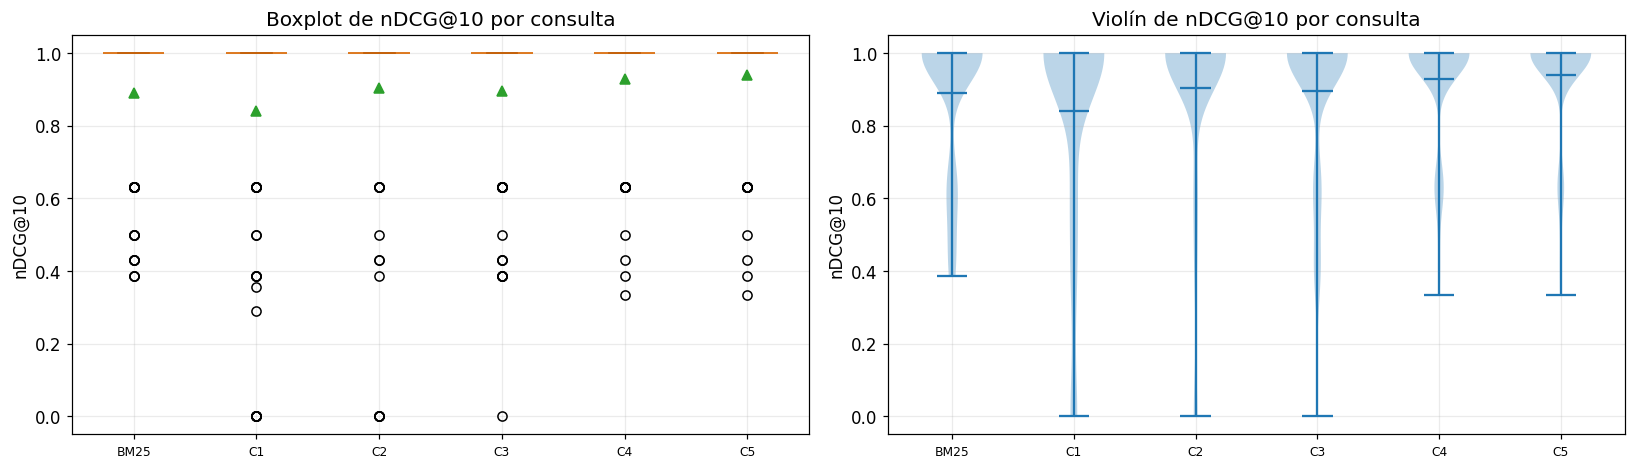

In [9]:
# Distribución por consulta: boxplot y violín de nDCG@10
_data = [[ndcg(_rank[n][c["id"]], qrels[c["id"]], 10) for c in _gold] for n in _orden]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
_bp = axes[0].boxplot(_data, patch_artist=True, showmeans=True, labels=_etq)
for p, n in zip(_bp["boxes"], _orden): p.set_facecolor(_COL[n]); p.set_alpha(0.7)
axes[0].set_title("Boxplot de nDCG@10 por consulta"); axes[0].set_ylabel("nDCG@10"); axes[0].tick_params(axis="x", labelsize=8)
axes[1].violinplot(_data, showmeans=True); axes[1].set_xticks(range(1, len(_orden) + 1))
axes[1].set_xticklabels(_etq, fontsize=8); axes[1].set_title("Violín de nDCG@10 por consulta"); axes[1].set_ylabel("nDCG@10")
plt.tight_layout(); plt.show()

**Cobertura del ranking.** Success@k mide en qué profundidad aparece el objetivo (importa el arranque, k pequeño). Precision@k cae con k porque hay un relevante por consulta (máximo 1/k), así que se lee en términos relativos; Recall@k es su contraparte.

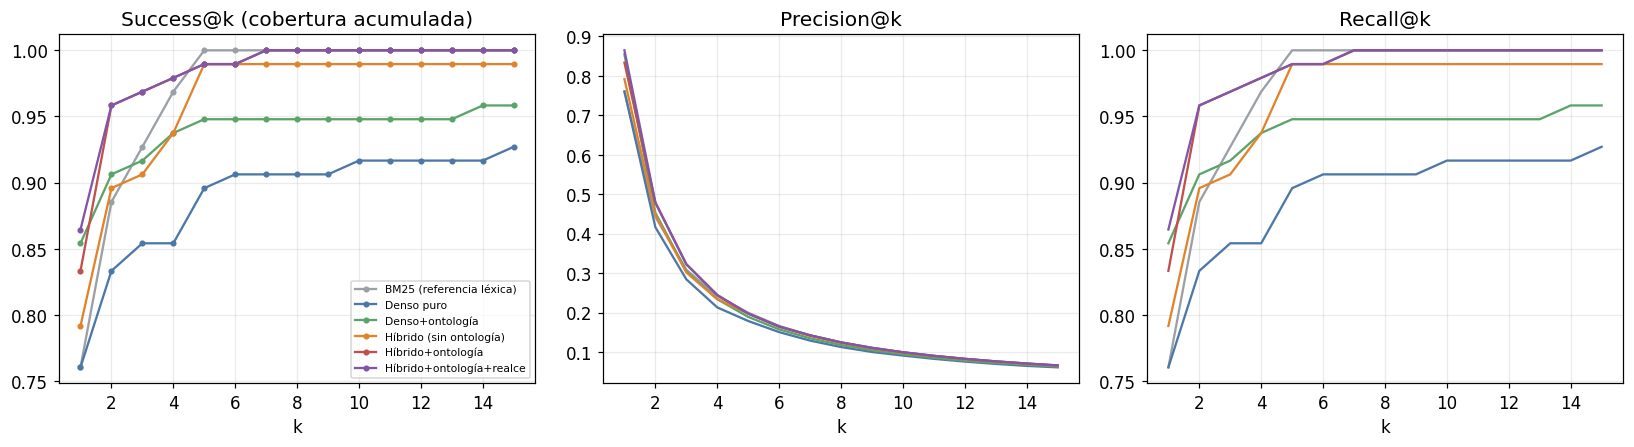

In [10]:
# Success@k (cobertura acumulada) + Precision@k + Recall@k
_ks = list(range(1, 16))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for n in _orden:
    axes[0].plot(_ks, [_np.mean([1.0 if any(qrels[c["id"]].get(d, 0) > 0 for d in _rank[n][c["id"]][:k]) else 0.0 for c in _gold]) for k in _ks], color=_COL[n], marker="o", ms=3, label=n.replace(" + ", "+"))
    axes[1].plot(_ks, [_np.mean([prec(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
    axes[2].plot(_ks, [_np.mean([recall(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
axes[0].set_title("Success@k (cobertura acumulada)"); axes[0].set_xlabel("k"); axes[0].legend(fontsize=7, loc="lower right")
axes[1].set_title("Precision@k"); axes[1].set_xlabel("k"); axes[2].set_title("Recall@k"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

**Score semántico vs relevancia.** Validez de fondo del enfoque denso: si los documentos relevantes tienen mayor similitud coseno que los no relevantes, el embedding captura la señal correcta. El solapamiento en la zona media explica por qué la señal léxica y la ontología siguen aportando.

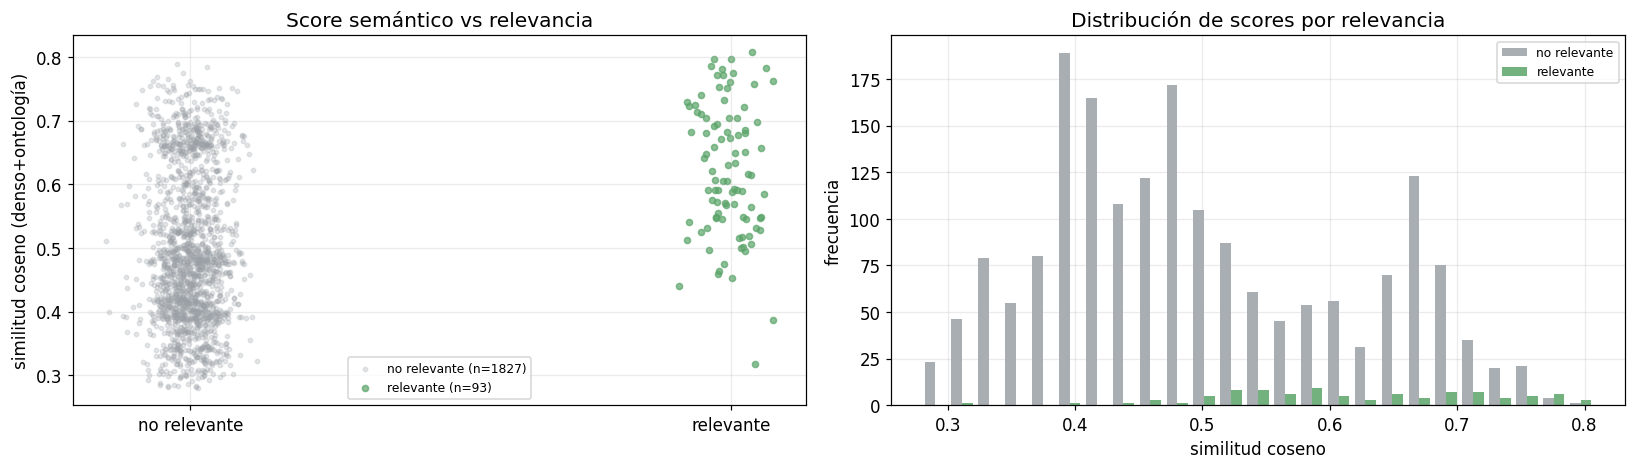

coseno medio -> relevantes=0.622 vs no relevantes=0.496 (separación=+0.126)


In [11]:
# Scatter: score semántico (coseno) vs relevancia
_xr, _xn = [], []
for c in consultas:
    for d, sc in mot.do.buscar(c["texto"])[:20]:
        (_xr if qrels.get(c["id"], {}).get(d, 0) > 0 else _xn).append(sc)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4)); _rng = _np.random.default_rng(0)
axes[0].scatter(_rng.normal(0, 0.04, len(_xn)), _xn, s=8, alpha=0.25, color="#9aa0a6", label=f"no relevante (n={len(_xn)})")
axes[0].scatter(_rng.normal(1, 0.04, len(_xr)), _xr, s=16, alpha=0.7, color="#5aa469", label=f"relevante (n={len(_xr)})")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["no relevante", "relevante"]); axes[0].set_ylabel("similitud coseno (denso+ontología)")
axes[0].set_title("Score semántico vs relevancia"); axes[0].legend(fontsize=8)
axes[1].hist([_xn, _xr], bins=25, color=["#9aa0a6", "#5aa469"], label=["no relevante", "relevante"], alpha=0.85)
axes[1].set_xlabel("similitud coseno"); axes[1].set_ylabel("frecuencia"); axes[1].set_title("Distribución de scores por relevancia"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"coseno medio -> relevantes={_np.mean(_xr):.3f} vs no relevantes={_np.mean(_xn):.3f} (separación={_np.mean(_xr)-_np.mean(_xn):+.3f})")

**Lectura conjunta.** Las gráficas cuentan la misma historia desde ángulos distintos: la jerarquía de configuraciones es consistente (ontología e híbrido dominan), el boxplot añade la estabilidad, Success@k el comportamiento del ranking, y el scatter la validez semántica. Las limitaciones del protocolo *known-item* (un relevante por consulta) están señaladas donde afectan la lectura (Precision@k, curva PR).

## 6. Conclusiones (Escalera 2)

**Interpretación de resultados.**
- **Recall@100 dejó de ser trivial.** Con cientos de documentos, el **denso puro pierde
  documentos relevantes** del top-100 mientras el híbrido y las variantes con ontología los
  retienen. Es la evidencia más clara, imposible de ver con 17 documentos, de que la señal
  léxica del híbrido es necesaria a escala.
- **La ontología es la que más aporta, y en Competencias más aún (P3).** En el dominio
  construido por composición ontológica, inyectar `φ(o_d)` es lo que mejor ordena; es el test
  más exigente y lo pasa.
- **El realce ayuda en entidad exacta a escala (P5).** Coherente con la Escalera 1: sobre
  consultas con nombre propio y muchos distractores, el realce sube el objetivo.
- **Impacto sobre P6:** con un índice de cientos de vectores, la memoria empieza a importar y
  la truncación Matryoshka (notebook 03) se vuelve una palanca real, no solo teórica.

**Cierre.** Competencias pasa de "vacío de cobertura medido" a "dominio recuperable con
objetivos reales". La misma tubería (`preprocess_corpus.py`) absorbió los nuevos documentos
sin rediseño, que era la promesa de la v2. El corpus ampliado, además, arregla las dos
limitaciones estadísticas de la v1 (Recall trivial y n pequeño).